simple example for pandas 

In [3]:
import pandas as pd

text = [
    "Hello WORLD!",
    "Pandas is GREAT",
    "Python is FUN",
    "Hello WORLD!",
]

df = pd.DataFrame({'tweet': text})

print(df)

             tweet
0     Hello WORLD!
1  Pandas is GREAT
2    Python is FUN
3     Hello WORLD!


    pandas DataFrame is a way to represent and work with tabular data. It can be seen as a table that organizes data into rows and columns, making it a two-dimensional data structure.
    
    pd.DataFrame({...}) → Creates a structured table from a dictionary.

    df['column'] → Accesses a column in the DataFrame.

You can delete columns, rows, using different DataFram API (for example drop_duplicates( ))


In [3]:
df.drop_duplicates()

,tweet
0,Hello WORLD!
1,Pandas is GREAT
2,Python is FUN


In [4]:
tweets = [
    "Hello WORLD!",
    "Pandas is GREAT",
    "Python is FUN",
    "Hello WORLD!",
]

retweets = [
200, 12, 3, 200
]

df2 = pd.DataFrame({
    'tweets': tweets,
    'retweets': retweets
})

print(df2)


            tweets  retweets
0     Hello WORLD!       200
1  Pandas is GREAT        12
2    Python is FUN         3
3     Hello WORLD!       200


In [10]:
df2.drop_duplicates()

,tweets,retweets
0,Hello WORLD!,200
1,Pandas is GREAT,12
2,Python is FUN,3


Text processing

1- Converting Text to Lowercase with a Lambda Expression

This step normalizes text by converting all words to lowercase.

Why this is useful in NLP:
- It treats `NLP`, `nlp`, and `Nlp` as the same token.
- It reduces vocabulary size before tokenization and modeling.

In [ ]:
# Convert each tweet to lowercase using a lambda expression
# split() -> lowercase each word -> join back into one string

df['tweet'] = df['tweet'].apply(
    lambda tweet: ' '.join(word.lower() for word in tweet.split())
)

# Display the processed column
df['tweet']

0       hello world!
1    pandas is great
2      python is fun
3       hello world!
Name: tweet, dtype: object

Explanation of the lambda expression:

- `df['tweet'].apply(...)`: applies a function to each row in the `tweet` column.
- `lambda tweet: ...`: defines a short function for each tweet.
- `tweet.split()`: splits the tweet string into words.
- `word.lower() for word in tweet.split()`: lowercases each word.
- `' '.join(...)`: joins the lowercase words back into a single sentence.

In [9]:
text=['This is introduction to NLP','It is likely to be useful , to people ','Machine learning is the new electrcity','There would be less hype around AI and more action going forward','python is the best tool!','R is good langauage','I like this book','I want more books like this']
df = pd.DataFrame({'tweet': text})
df['tweet'] = df['tweet'].apply(lambda tweet: " ".join(word.lower() for word in tweet.split()))
df['tweet']


0                          this is introduction to nlp
1                it is likely to be useful , to people
2               machine learning is the new electrcity
3    there would be less hype around ai and more ac...
4                             python is the best tool!
5                                  r is good langauage
6                                     i like this book
7                          i want more books like this
Name: tweet, dtype: object

------------------------------------------------------------------

2- remove punctuation

In [17]:
text=['This is introduction to NLP','It is likely to be useful, to people ','Machine learning is the new electrcity','There would be less hype around AI and more action going forward','python is the best tool!','R is good langauage', 'I like this book','I want more books like this']
import pandas as pd
df = pd.DataFrame({'tweet':text})
df['tweet'] = df['tweet'].str.replace('[^\\w\\s]',"", regex=True)
# or you can use str.replace(r'[^\w\s]')
df['tweet']


0                          This is introduction to NLP
1                 It is likely to be useful to people 
2               Machine learning is the new electrcity
3    There would be less hype around AI and more ac...
4                              python is the best tool
5                                  R is good langauage
6                                     I like this book
7                          I want more books like this
Name: tweet, dtype: object

 Clean the tweet text by removing punctuation:
 - str.replace() is used to replace patterns in string data
 - [^\w\s] is a regular expression pattern that matches:
   where \w = [a-zA-Z0-9_]
   \s = any whitespace character: space, new line, tab, 
 - The matched characters are replaced with an empty string (removed)
 - [^\\w\\s] → Match any character that is not a word character (\w) and not a whitespace (\s).

In [35]:
# using Python's built-in string.punctuation
# string.punctuation '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'
import string
s = "I. like. This book!"
for c in string.punctuation:
    s= s.replace(c,"")
s

'I like This book'

    Iterates over each punctuation character (c) in string.punctuation.

    For each punctuation mark, it replaces all occurrences in s with an empty string (""), effectively deleting it.

---------------------------------------------------------------------

Stop words removal

Stop words are common words that appear frequently in a language but carry little meaningful information for text analysis. Removing them is a crucial preprocessing step in Natural Language Processing (NLP)

Reduces Noise
Stop words (e.g., "the," "is," "and") dominate text but don’t contribute to meaning. Removing them highlights key terms.

Improves Efficiency
Fewer words = faster processing for tasks like search engines, sentiment analysis, or machine learning.

but there are some cases where you might need to keep the stop words for example: machine translation.

In [31]:
text=['This is introduction to NLP','It is likely to be useful, to people ','Machine learning is the new electrcity','There would be less hype around AI and more action going forward','python is the best tool!','R is good langauage','I like this book','I want more books like this']
import pandas as pd
df = pd.DataFrame({'tweet':text})
# print(df)
import nltk
# nltk.download()
from nltk.corpus import stopwords
#remove stop words
stop = stopwords.words('english')
# print(stop)
df['tweet'] = df['tweet'].apply( lambda x: " ".join(word for word in x.split() if word.lower() not in stop))
df['tweet']

0                                  introduction NLP
1                             likely useful, people
2                   Machine learning new electrcity
3    would less hype around AI action going forward
4                                 python best tool!
5                                  R good langauage
6                                         like book
7                                   want books like
Name: tweet, dtype: object

-------------------------------------------------------------------------


Text standardization is the process of converting text into a consistent, normalized format. It's used to:

    Improve NLP Accuracy

        Reduces noise (e.g., slang, abbreviations, typos) for machine learning models.

    Enhance Search & Analysis

        Ensures "NLP", "nlp", and "Natural Language Processing" are treated as the same term.

    Preprocess Social Media/User-Generated Text

        Normalizes informal language (e.g., "ur" → "your").

In [39]:
lookup_dict = {
    'nlp': 'natural language processing',
    'ur': 'your', 
    'wbu': 'what about you'
}

# Maps abbreviations/slang to standardized forms.

import re
#  Python's regular expression (regex) module
def text_std(input_text):
    words = input_text.split()
    new_words = []
    
    for word in words:
        word = re.sub(r'[^\w\s]', '', word)  # Remove punctuation: Substitute (replace) parts of a string that match a regex pattern.
        if word.lower() in lookup_dict:
            word = lookup_dict[word.lower()]  # Replace using dictionary
        new_words.append(word)
    
    return " ".join(new_words)  # Rejoin into a sentence

In [37]:
text_std("I like nlp, it's ur choice!")

'I like natural language processing its your choice'

------------------------------------------------------------

Spelling correction 

In [43]:
ext=['Introdaction to NLP','It is likely to be useful, to people ','Machin learning is the new electrcity', 'R is good langauage','I like this book','I want more books like this']
import pandas as pd
df = pd.DataFrame({'tweet':text})
print(df)
# TextBlob is a Python library for processing textual data. 
# It provides a simple API for diving into common natural language processing (NLP) tasks
from textblob import TextBlob
df['tweet'].apply(lambda x: str(TextBlob(x).correct()))

                                               tweet
0                        This is introduction to NLP
1              It is likely to be useful, to people 
2             Machine learning is the new electrcity
3  There would be less hype around AI and more ac...
4                           python is the best tool!
5                                R is good langauage
6                                   I like this book
7                        I want more books like this


0                           His is introduction to NLP
1                It is likely to be useful, to people 
2              Machine learning is the new electricity
3    There would be less hope around of and more ac...
4                             patron is the best tool!
5                                   R is good language
6                                     I like this book
7                          I want more books like this
Name: tweet, dtype: object

In [45]:
!pip install autocorrect

In [51]:
from autocorrect import Speller
spell = Speller()
print(spell(u'mussage'))
print(spell(u'sirvice'))

message
service


----------------------------------------------------------

Tokenization (agian :) )

In [14]:
text=['This is introduction to NLP','It is likely to be useful, to people ','Machine learning is the new electrcity', 'There would be less hype around AI and more action going forward.','python is the best tool!','R is good  langauage', 'I like this book','I want more books like this']
import pandas as pd
df = pd.DataFrame({'tweet':text})
print(df)


                                               tweet
0                        This is introduction to NLP
1              It is likely to be useful, to people 
2             Machine learning is the new electrcity
3  There would be less hype around AI and more ac...
4                           python is the best tool!
5                               R is good  langauage
6                                   I like this book
7                        I want more books like this


In [15]:
from textblob import TextBlob
TextBlob(df['tweet'][3]).words

WordList(['There', 'would', 'be', 'less', 'hype', 'around', 'AI', 'and', 'more', 'action', 'going', 'forward'])

In [11]:
#using split function from python
mystring = "My favorite animal. is wolf"
mystring.split()


['My', 'favorite', 'animal.', 'is', 'wolf']

---------------------------------------------------------------

Stemming reduces words to their root form (or stem) by chopping off prefixes/suffixes.

Normalizes Variations

    Treats similar words as the same term:

        "running", "runs", "ran" → all become "run"

        "connected", "connecting" → "connect"

Improves Text Analysis

    Helps algorithms focus on core meaning rather than surface forms.

    Example: A search for "jumping" will also match "jumped" in documents.

Reduces Data Complexity

    Fewer unique words = simpler models and faster processing.

    Critical for tasks like:

        Search engines

        Spam detection

        Topic modeling

In [57]:
text=['I like fishing','I eat fish','There are many fishes in pound']
import pandas as pd
df = pd.DataFrame({'tweet':text})
from nltk.stem import PorterStemmer
st = PorterStemmer()
df['tweet'][:5].apply(lambda x: " ".join([st.stem(word) for word in x.split()]))

0                     i like fish
1                      i eat fish
2    there are mani fish in pound
Name: tweet, dtype: object

famous stemmers 

Porter Stemmer

Snowball Stemmer (Porter2) 

ISRI (for arabic)

--------------------------------------------------------------------------------

lemmatization 

The difference between lemmatization and stemming lies in how they reduce words to their base or root 

Stemming:
- Chops off prefixes/suffixes
- May not be a real word
- Rule-based, often crude
- Ignores word meaning/grammar
  

Lemmatization:
- Returns the base dictionary form
- Always a valid word
- Dictionary-based (accurate but slower)
- Considers part-of-speech (POS) and meaning

In [59]:
text=['I like fishing','I eat fish','There are many fishes in pound', 'leaves and leaf']
#convert list to dataframe
import pandas as pd
df = pd.DataFrame({'tweet':text})
# print(df)
#Import library
from textblob import Word
#Code for lemmatize
df['tweet'] = df['tweet'].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()]))
df['tweet']

0                  I like fishing
1                      I eat fish
2    There are many fish in pound
3                   leaf and leaf
Name: tweet, dtype: object

In [10]:
text=['I like fishing','I eat fish','There are many fishes in pound', 'leaves and leaf']
#convert list to dataframe
import pandas as pd
df = pd.DataFrame({'tweet':text})
# print(df)
#Import library
from textblob import Word
#Code for lemmatize
df['tweet'] = df['tweet'].apply(lambda x: " ".join([Word(word).lemmatize('v') for word in x.split()]))
df['tweet']
# 'v' parameter forces verb lemmatization

0                    I like fish
1                     I eat fish
2    There be many fish in pound
3                 leave and leaf
Name: tweet, dtype: object

--------------------------------------------------

In [11]:
import nltk
from nltk.corpus import webtext
# nltk.download('webtext') 
# The webtext corpus in NLTK is a small collection of text
# from web pages, intended for experimentation and educational use. It contains real-world, informal English

In [12]:
wt_sentences = webtext.sents('firefox.txt')  # List of sentences
wt_words = webtext.words('firefox.txt')      # List of words
len(wt_sentences)  # Counts total sentences
# webtext.sents(): Returns sentences from the corpus file (firefox.txt).
# webtext.words(): Returns words from the corpus file.

1144

In [13]:
for sent in wt_sentences:
    print(sent)

['Cookie', 'Manager', ':', '"', 'Don', "'", 't', 'allow', 'sites', 'that', 'set', 'removed', 'cookies', 'to', 'set', 'future', 'cookies', '"', 'should', 'stay', 'checked', 'When', 'in', 'full', 'screen', 'mode', 'Pressing', 'Ctrl', '-', 'N', 'should', 'open', 'a', 'new', 'browser', 'when', 'only', 'download', 'dialog', 'is', 'left', 'open', 'add', 'icons', 'to', 'context', 'menu', 'So', 'called', '"', 'tab', 'bar', '"', 'should', 'be', 'made', 'a', 'proper', 'toolbar', 'or', 'given', 'the', 'ability', 'collapse', '/', 'expand', '.']
['[', 'XUL', ']', 'Implement', 'Cocoa', '-', 'style', 'toolbar', 'customization', '.']
['#', 'ifdefs', 'for', 'MOZ_PHOENIX', 'customize', 'dialog', "'", 's', 'toolbar', 'has', 'small', 'icons', 'when', 'small', 'icons', 'is', 'not', 'checked', 'nightly', 'builds', 'and', 'tinderboxen', 'for', 'Phoenix', 'finish', 'tearing', 'prefs', 'UI', 'to', 'pieces', 'and', 'then', 'make', 'it', 'not', 'suck', '"', 'mozbrowser', '"', 'script', 'doesn', "'", 't', 'start'

In [15]:
# Frequency Distribution Analysis
# FreqDist (Frequency Distribution) is a class from the nltk.probability module
# that counts the frequency of each item (usually words) in a given sequence
from nltk.probability import FreqDist
frequency_dist = nltk.FreqDist(wt_words)  # Computes word frequencies
sorted_frequency_dist = sorted(frequency_dist, key=frequency_dist.__getitem__, reverse=True)
print(sorted_frequency_dist)

['.', 'in', 'to', '"', 'the', "'", 'not', '-', 'when', 'on', 'a', 'is', 't', 'and', 'of', '(', 'page', 'for', 'with', ')', 'window', 'Firefox', 'does', 'from', 'open', ':', 'menu', 'should', 'bar', 'tab', 'doesn', 'after', 'Firebird', 'new', 'work', 'browser', 'if', 'be', '0', 'toolbar', 'button', 'bookmarks', 'dialog', 'bookmark', 'as', 'file', 'URL', 'download', 'crashes', 'I', 'no', 'text', 'are', 'or', 'up', 'crash', 'click', 'tabs', 'Bookmarks', 'link', '/', 'firefox', 'manager', '+', 'using', 'it', 'Mozilla', 'default', 'error', 'all', 'an', 'clicking', 's', 'windows', 'search', 'folder', ']', 'Phoenix', '1', 'at', 'icon', 'Manager', 'by', 'this', 'site', 'can', 'files', 'Page', 'fails', 'causes', 'use', 'close', '[', 'opening', 'Toolbar', 'Add', 'has', 'Bookmark', 'right', 'display', 'down', 'that', 'theme', 'box', 'Download', '9', 'The', 'pages', 'firebird', 'only', 'url', 'while', 'have', 'image', 'links', 'When', 'location', 'Crash', 'option', 'scroll', 'load', 'cannot', 'Opt

In [16]:
print(frequency_dist.most_common())

[('.', 2428), ('in', 2203), ('to', 2130), ('"', 1971), ('the', 1762), ("'", 1507), ('not', 1472), ('-', 1372), ('when', 1255), ('on', 1193), ('a', 1172), ('is', 1016), ('t', 964), ('and', 881), ('of', 869), ('(', 770), ('page', 719), ('for', 713), ('with', 680), (')', 645), ('window', 607), ('Firefox', 602), ('does', 594), ('from', 506), ('open', 479), (':', 466), ('menu', 462), ('should', 461), ('bar', 458), ('tab', 456), ('doesn', 453), ('after', 444), ('Firebird', 437), ('new', 429), ('work', 414), ('browser', 392), ('if', 390), ('be', 376), ('0', 376), ('toolbar', 364), ('button', 363), ('bookmarks', 352), ('dialog', 330), ('bookmark', 329), ('as', 324), ('file', 315), ('URL', 304), ('download', 297), ('crashes', 291), ('I', 289), ('no', 280), ('text', 279), ('are', 275), ('or', 274), ('up', 268), ('crash', 258), ('click', 253), ('tabs', 246), ('Bookmarks', 245), ('link', 244), ('/', 237), ('firefox', 236), ('manager', 229), ('+', 224), ('using', 222), ('it', 221), ('Mozilla', 220)

In [21]:
print(frequency_dist.items())

dict_items([('Cookie', 22), ('Manager', 179), (':', 466), ('"', 1971), ('Don', 21), ("'", 1507), ('t', 964), ('allow', 53), ('sites', 63), ('that', 145), ('set', 109), ('removed', 21), ('cookies', 57), ('to', 2130), ('future', 4), ('should', 461), ('stay', 21), ('checked', 22), ('When', 132), ('in', 2203), ('full', 38), ('screen', 101), ('mode', 51), ('Pressing', 9), ('Ctrl', 96), ('-', 1372), ('N', 1), ('open', 479), ('a', 1172), ('new', 429), ('browser', 392), ('when', 1255), ('only', 139), ('download', 297), ('dialog', 330), ('is', 1016), ('left', 75), ('add', 93), ('icons', 106), ('context', 104), ('menu', 462), ('So', 1), ('called', 16), ('tab', 456), ('bar', 458), ('be', 376), ('made', 16), ('proper', 6), ('toolbar', 364), ('or', 274), ('given', 15), ('the', 1762), ('ability', 25), ('collapse', 15), ('/', 237), ('expand', 29), ('.', 2428), ('[', 156), ('XUL', 13), (']', 189), ('Implement', 25), ('Cocoa', 1), ('style', 40), ('customization', 16), ('#', 13), ('ifdefs', 3), ('for', 

In [82]:
print(sorted_frequency_dist)

['.', 'in', 'to', '"', 'the', "'", 'not', '-', 'when', 'on', 'a', 'is', 't', 'and', 'of', '(', 'page', 'for', 'with', ')', 'window', 'Firefox', 'does', 'from', 'open', ':', 'menu', 'should', 'bar', 'tab', 'doesn', 'after', 'Firebird', 'new', 'work', 'browser', 'if', 'be', '0', 'toolbar', 'button', 'bookmarks', 'dialog', 'bookmark', 'as', 'file', 'URL', 'download', 'crashes', 'I', 'no', 'text', 'are', 'or', 'up', 'crash', 'click', 'tabs', 'Bookmarks', 'link', '/', 'firefox', 'manager', '+', 'using', 'it', 'Mozilla', 'default', 'error', 'all', 'an', 'clicking', 's', 'windows', 'search', 'folder', ']', 'Phoenix', '1', 'at', 'icon', 'Manager', 'by', 'this', 'site', 'can', 'files', 'Page', 'fails', 'causes', 'use', 'close', '[', 'opening', 'Toolbar', 'Add', 'has', 'Bookmark', 'right', 'display', 'down', 'that', 'theme', 'box', 'Download', '9', 'The', 'pages', 'firebird', 'only', 'url', 'while', 'have', 'image', 'links', 'When', 'location', 'Crash', 'option', 'scroll', 'load', 'cannot', 'Opt

<Axes: xlabel='Samples', ylabel='Counts'>

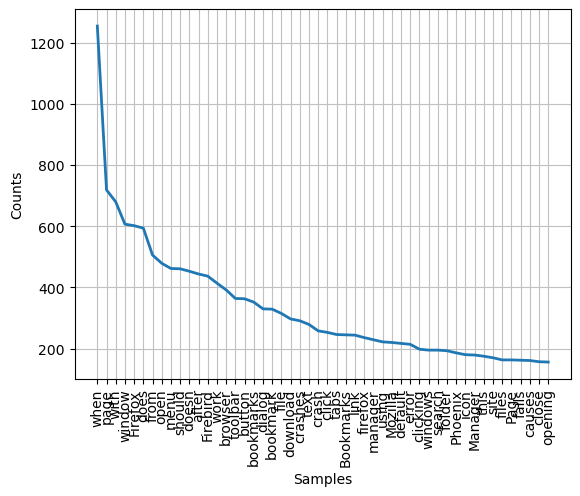

In [17]:
large_words = dict([(k, v) for k, v in frequency_dist.items() if len(k) > 3]) # words more than 3 characters 
frequency_dist = nltk.FreqDist(large_words) # Converts large_words back into a FreqDist
frequency_dist.plot(50, cumulative=False)

Generating a Word Cloud

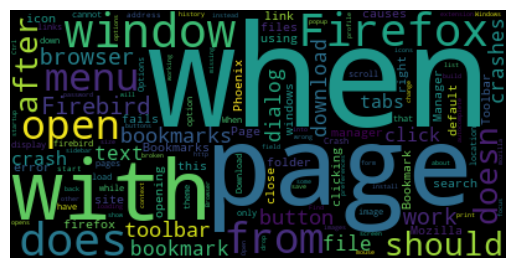

In [89]:
!pip install wordcloud
from wordcloud import WordCloud
wcloud = WordCloud().generate_from_frequencies(frequency_dist)

import matplotlib.pyplot as plt
plt.imshow(wcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

------------------------------------------------------------------

## Student Task

We have some posts on our social network today , and we want to know the top 5 treniding words for today
Compre the resutls between with pre-processing and no pre-processing

In [1]:
posts = [
    "Just attended an AMAZING #DataScience workshop! Learnt so much about PYTHON 🐍",
    "Can't decide between R and Python for data analysis... any suggestions? #stats",
    "Machine Learning is revolutionizin the healthcare industry! #AI #FutureTech",
    "Struggling with my pandas homework... DataFrames are trickier than I thot! 😅",
    "Big data is changing EVERYTHING! #tech #innovation",
    "Just got certified in NLP! Natural Language Processing is sooo cool! #proud",
    "Why do all my data vizualizations look ugly? Need help with matplotlib!",
    "AI will replace 40% of jobs in next decade... scary or exciting? #futureofwork",
    "Trying to learn Pytorch but the documentation is confusin... any tips?",
    "Data scientists: what's your favorite tool - Jupyter or VS Code? #discussion",
    "Just found out I've been using wrong loss function in my model for WEEKS! #fail",
    "Python vs Julia for scientific computing? Which one shud I learn?",
    "My neural network keeps overfitting... regularization is HARD! #MLstruggles",
    "Anyone else think SQL is underrated for data analysis? #databases",
    "Spent 4 hours debugging... turns out it was a missing comma! #codinglife",
    "Why is data cleaning taking 80% of my time? Is this normal? #datapreprocessing",
    "Just discovered list comprehensions in Python - mind BLOWN! #coding",
    "Keras or TensorFlow for deep learning beginners? Which is EZer to start with?",
    "My boss asked for 'big data insights' but we only have 1000 rows... lol",
    "How important is calculus REALLY for machine learning? #MLquestions"
]

In [2]:
# your soluton goes here